In [10]:
# 0. Configuración y carga de librerías
import os
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

os.chdir("..")
print("Working dir:", os.getcwd())

Working dir: c:\Users\Ella es ella\Documents\kedro_projects\nhanes-htn


In [11]:
# 1. Carga de datos de modelado
features = pd.read_csv("data/05_model_input/nhanes_features_selected.csv")
supervised = pd.read_csv("data/03_primary/nhanes_supervised_dataset.csv")

print("features shape:", features.shape)
print("supervised shape:", supervised.shape)

features.head()


features shape: (11268, 16)
supervised shape: (11268, 34)


,age_years,income_poverty_ratio,gender_code,race_ethnicity_code,education_level_code,bmi,waist_cm,transport_activity_code,transport_activity_minutes,vigorous_recreation_code,vigorous_recreation_minutes,moderate_recreation_code,moderate_recreation_minutes,work_activity_code,work_activity_minutes,sedentary_minutes
0,0.704896,1.307607,1,3,5,-0.237956,0.080069,2,-0.309377,2,-0.448176,1,0.093001,1,-0.468506,0.643800
1,0.219927,-0.720051,1,3,3,0.177939,0.492555,2,-0.309377,2,-0.448176,2,-0.535054,2,-0.549369,-0.258061
2,1.567064,-0.594561,1,3,3,-0.099325,1.014228,2,-0.309377,2,-0.448176,2,-0.535054,1,1.391351,0.643800
3,0.381584,1.710497,2,3,5,1.786068,0.626006,2,-0.309377,2,-0.448176,2,-0.535054,1,0.178401,0.643800
4,-0.372813,-0.779494,2,4,4,-1.277695,-1.175587,2,-0.309377,2,-0.448176,2,-0.535054,1,3.332072,0.944420


1. Explicación

En esta sección se cargan los datasets finales generados por el pipeline de ingeniería de datos:

* nhanes_supervised_dataset: incluye SBP_mean, DBP_mean y HTN_label.

* nhanes_features_selected: solo las features elegidas para modelar.

In [12]:
# 2. Carga de modelos y métricas desde el pipeline supervised_models
# Modelos
reg_model = joblib.load("data/06_models/regression_model.pkl")
clf_model = joblib.load("data/06_models/classification_model.pkl")

# Métricas
with open("data/08_reporting/regression_metrics.json", "r") as f:
    reg_metrics = json.load(f)

with open("data/08_reporting/classification_metrics.json", "r") as f:
    clf_metrics = json.load(f)

reg_metrics


{'linear_regression': {'rmse_train': 16.41964104752413,
  'rmse_test': 16.182606059613256,
  'r2_train': 0.23808996467098043,
  'r2_test': 0.26035331284194985},
 'random_forest': {'rmse_train': 6.107100778937262,
  'rmse_test': 16.02453978738151,
  'r2_train': 0.8945985586293695,
  'r2_test': 0.2747319870466963},
 'best_model': 'random_forest'}

In [13]:
# 2.1 Visualización de métricas en forma de tabla de regresion
reg_metrics_df = (
    pd.DataFrame(reg_metrics)
    .T
    .drop("best_model", errors="ignore")
)
reg_metrics_df


,rmse_train,rmse_test,r2_train,r2_test
linear_regression,16.419641,16.182606,0.23809,0.260353
random_forest,6.107101,16.02454,0.894599,0.274732


### Resultados de regresión: predicción de SBP_mean

La tabla siguiente resume el desempeño de los modelos de regresión en el conjunto de entrenamiento y prueba. Se reportan el error cuadrático medio (RMSE) y el coeficiente de determinación (R²).

- **linear_regression**  
  - RMSE_train ≈ 16.42  
  - RMSE_test ≈ 16.18  
  - R²_train ≈ 0.24  
  - R²_test ≈ 0.26  

- **random_forest**  
  - RMSE_train ≈ 6.11  
  - RMSE_test ≈ 16.02  
  - R²_train ≈ 0.89  
  - R²_test ≈ 0.27  

En test, ambos modelos explican alrededor del 26–27 % de la variabilidad de la presión sistólica promedio. El random forest ajusta mucho mejor los datos de entrenamiento (R² ≈ 0.89) que los de prueba, lo que sugiere sobreajuste, mientras que la regresión lineal muestra un ajuste más pobre pero estable.

In [14]:
# 2.2 Visualización de métricas en forma de tabla de clasificación
clf_metrics_df = (
    pd.DataFrame(clf_metrics)
    .T
    .drop("best_model", errors="ignore")
)
clf_metrics_df


,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
logistic_regression,0.684117,0.36875,0.769565,0.498592,0.773432
random_forest,0.795918,0.5,0.086957,0.148148,0.766406
svc_rbf,0.642413,0.347443,0.856522,0.494354,0.780932
knn,0.787489,0.411215,0.095652,0.155203,0.72883


### Sección 2 – Reconstruir train/test para hacer gráficas

In [15]:
# 3. División train/test reproducible para análisis
from sklearn.model_selection import train_test_split

X = features.copy()
y_reg = supervised["SBP_mean"]
y_clf = supervised["HTN_label"].astype(int)

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X,
    y_reg,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf,
)

X_train.shape, X_test.shape


((9014, 16), (2254, 16))

3. Explicación

Se replica el particionado utilizado en el pipeline (test_size = 0.2, random_state = 42, estratificado en HTN_label).

### Sección 3 – Resultados de regresión

In [16]:
# 4. Resultados de regresión – Predicción de SBP_mean
print("Modelo de regresión seleccionado por el pipeline:",
      reg_metrics.get("best_model", "no definido"))

reg_metrics_df


Modelo de regresión seleccionado por el pipeline: random_forest


,rmse_train,rmse_test,r2_train,r2_test
linear_regression,16.419641,16.182606,0.23809,0.260353
random_forest,6.107101,16.02454,0.894599,0.274732


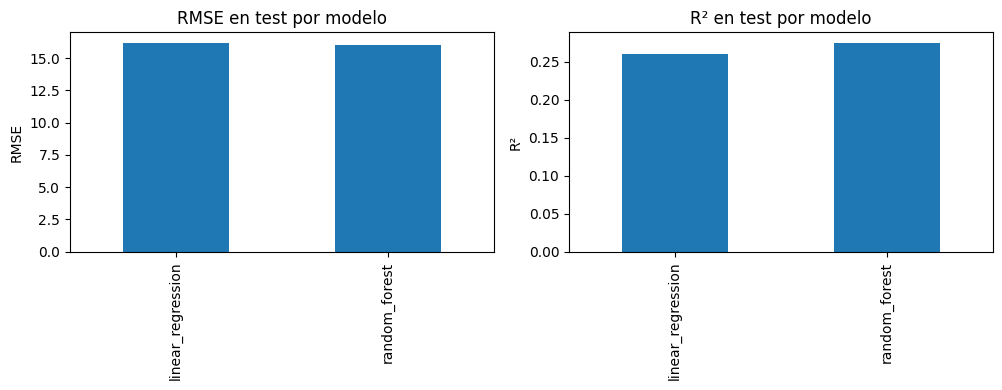

In [17]:
# 4.1 Cuadro de comparación R² y RMSE entre modelos
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

reg_metrics_df["rmse_test"].plot(kind="bar", ax=axes[0])
axes[0].set_title("RMSE en test por modelo")
axes[0].set_ylabel("RMSE")

reg_metrics_df["r2_test"].plot(kind="bar", ax=axes[1])
axes[1].set_title("R² en test por modelo")
axes[1].set_ylabel("R²")

plt.tight_layout()
plt.show()


### Comparación gráfica de modelos de regresión (RMSE y R² en test)

Los gráficos de barras muestran el RMSE y el R² en el conjunto de prueba para cada modelo de regresión.

- Ambos modelos tienen RMSE muy similar (≈ 16 mmHg).  
- El random forest alcanza un R² de test levemente mayor que la regresión lineal (≈ 0.27 vs 0.26).  
- La diferencia visual refuerza que ningún modelo logra capturar más de un tercio de la variabilidad de SBP_mean, aunque el random forest es ligeramente superior en términos de poder explicativo.


RMSE en este split: 16.02
R² en este split: 0.275


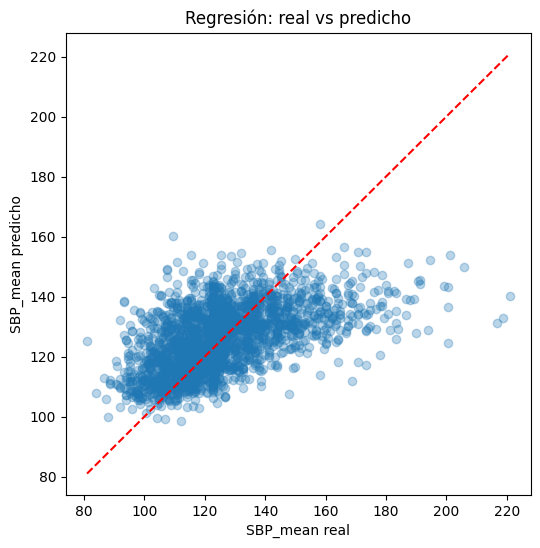

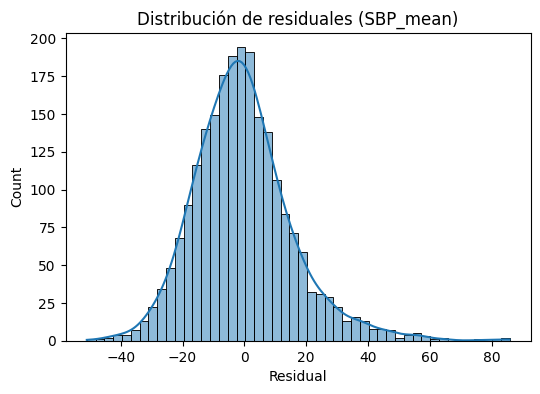

In [19]:
# 4.2 Cuadro de comparación de resultados. Predicho VS real y residuales
from sklearn.metrics import mean_squared_error, r2_score

y_pred_test_reg = reg_model.predict(X_test)

# Some sklearn versions don't accept the 'squared' kwarg — compute RMSE explicitly
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_test_reg))
r2 = r2_score(y_reg_test, y_pred_test_reg)

print(f"RMSE en este split: {rmse:.2f}")
print(f"R² en este split: {r2:.3f}")

# Predicho vs real
plt.figure(figsize=(6, 6))
plt.scatter(y_reg_test, y_pred_test_reg, alpha=0.3)
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         "r--")
plt.xlabel("SBP_mean real")
plt.ylabel("SBP_mean predicho")
plt.title("Regresión: real vs predicho")
plt.show()

# Histograma de residuales
residuals = y_reg_test - y_pred_test_reg
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.title("Distribución de residuales (SBP_mean)")
plt.xlabel("Residual")
plt.show()


### Dispersión de SBP_mean real vs predicho (mejor modelo de regresión)

El gráfico de dispersión compara los valores reales de SBP_mean con las predicciones del modelo de regresión seleccionado (random forest). La línea roja punteada representa la identidad (predicción perfecta).

- Los puntos se alinean de forma general con la diagonal, pero con una dispersión importante.  
- El modelo tiende a subestimar valores altos de SBP_mean y a sobreestimar algunos valores bajos.  
- El ajuste global es moderado, coherente con un R² en torno a 0.27.

Este gráfico ilustra que, aunque el modelo captura cierta tendencia entre las variables de entrada y la presión sistólica, persiste una cantidad considerable de error aleatorio.


### Distribución de residuales del modelo de regresión

El histograma muestra la distribución de los residuales (SBP_mean real − SBP_mean predicho) para el modelo de regresión.

- La forma es aproximadamente simétrica y cercana a una distribución normal, centrada en torno a 0.  
- Existe algo de cola hacia la derecha, reflejando algunos casos donde el modelo subestima valores altos de presión.  
- La ausencia de sesgos extremos sugiere que el modelo no comete errores sistemáticos muy marcados, pero la amplitud de los residuales confirma un error de predicción relevante a nivel individual.

Esta distribución respalda el uso de métricas basadas en el error cuadrático, aunque advierte que el modelo tiene precisión limitada en sujetos concretos.


### Sección 4 – Resultados de clasificación

In [20]:
# 5. Resultados de clasificacion - Predicción de HTN_label
print("Clasificador seleccionado por el pipeline:",
      clf_metrics.get("best_model", "no definido"))

clf_metrics_df

Clasificador seleccionado por el pipeline: logistic_regression


,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
logistic_regression,0.684117,0.36875,0.769565,0.498592,0.773432
random_forest,0.795918,0.5,0.086957,0.148148,0.766406
svc_rbf,0.642413,0.347443,0.856522,0.494354,0.780932
knn,0.787489,0.411215,0.095652,0.155203,0.72883


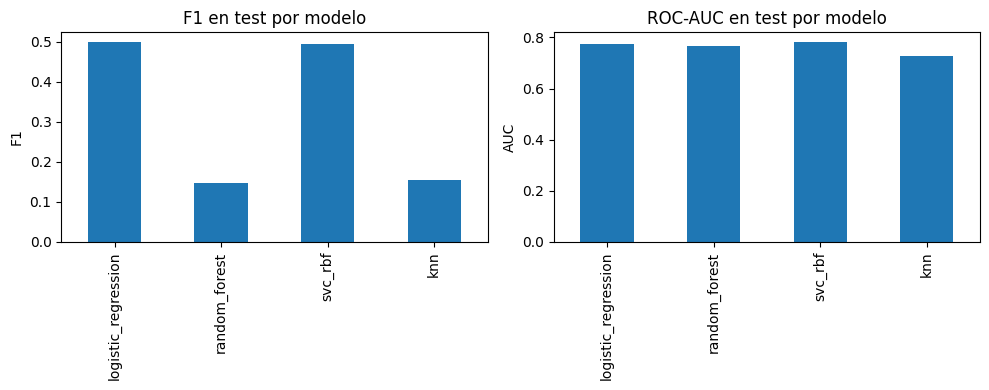

In [21]:
# 5.1 Comparación de resultados. F1 VS AUC
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

clf_metrics_df["f1_test"].plot(kind="bar", ax=axes[0])
axes[0].set_title("F1 en test por modelo")
axes[0].set_ylabel("F1")

if "roc_auc_test" in clf_metrics_df.columns:
    clf_metrics_df["roc_auc_test"].plot(kind="bar", ax=axes[1])
    axes[1].set_title("ROC-AUC en test por modelo")
    axes[1].set_ylabel("AUC")

plt.tight_layout()
plt.show()


### Comparación gráfica de clasificadores (F1 y ROC-AUC)

Los gráficos de barras resumen el desempeño de los clasificadores en el conjunto de prueba:

- El F1 es mayor para **logistic_regression** y **svc_rbf** (≈ 0.49–0.50), indicando mejor equilibrio entre precisión y recall en la clase hipertensa.  
- El ROC-AUC es similar para logística, random forest y SVC (≈ 0.77–0.78), lo que implica capacidad discriminativa comparable si se ajusta adecuadamente el umbral de decisión.  
- KNN y random forest logran accuracies altas pero F1 bajos, porque casi nunca predicen la clase positiva.

Estos gráficos refuerzan que el criterio de selección debe basarse en F1 y AUC, más que en accuracy simple, dada la desproporción entre clases.


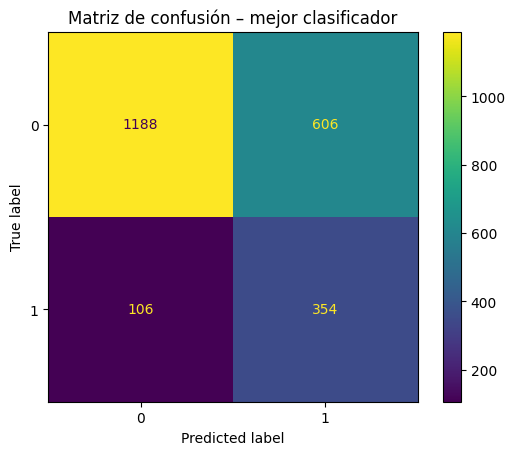

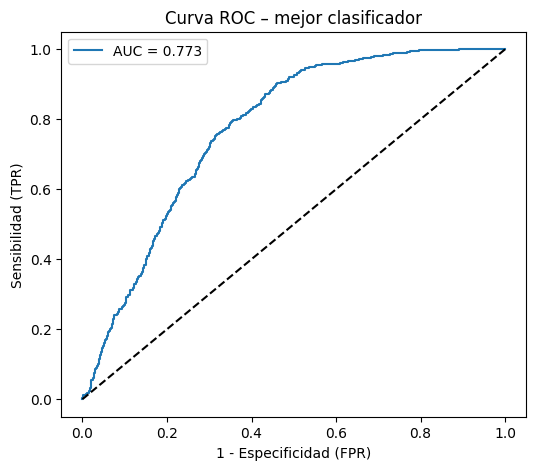

In [22]:
# 5.2 Matriz de confusión y curva ROC del mejor clasificador
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

# Predicciones
y_pred_test_clf = clf_model.predict(X_test)

if hasattr(clf_model, "predict_proba"):
    y_proba_test_clf = clf_model.predict_proba(X_test)[:, 1]
else:
    # decisión reescalada si no hay predict_proba
    scores = clf_model.decision_function(X_test)
    y_proba_test_clf = (scores - scores.min()) / (scores.max() - scores.min())

# Matriz de confusión
cm = confusion_matrix(y_clf_test, y_pred_test_clf)
disp = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
disp.plot(values_format="d")
plt.title("Matriz de confusión – mejor clasificador")
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_clf_test, y_proba_test_clf)
auc_val = roc_auc_score(y_clf_test, y_proba_test_clf)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("1 - Especificidad (FPR)")
plt.ylabel("Sensibilidad (TPR)")
plt.title("Curva ROC – mejor clasificador")
plt.legend()
plt.show()


### Matriz de confusión del mejor clasificador (regresión logística)

La matriz de confusión para la regresión logística permite visualizar cómo se distribuyen aciertos y errores:

- Verdaderos negativos (TN): 1188  
- Falsos positivos (FP): 606  
- Falsos negativos (FN): 106  
- Verdaderos positivos (TP): 354  

El modelo detecta aproximadamente el 77 % de los hipertensos (recall alto), pero al costo de un número considerable de falsos positivos. Esta configuración prioriza la sensibilidad, lo que puede ser razonable en un contexto clínico donde es preferible evaluar más pacientes que dejar hipertensos sin identificar.

### Curva ROC y área bajo la curva (AUC) – regresión logística

La curva ROC muestra la relación entre sensibilidad (TPR) y 1 − especificidad (FPR) para distintos umbrales de decisión del modelo de regresión logística.

- El área bajo la curva (AUC) es ≈ 0.77.  
- La curva se sitúa claramente por encima de la diagonal, lo que indica un poder discriminativo sustancialmente mejor que el azar.  

Este gráfico sugiere que existe margen para ajustar el umbral de probabilidad de hipertensión según las necesidades clínicas (mayor sensibilidad vs mayor especificidad).


### Sección 5 – Importancia de variables

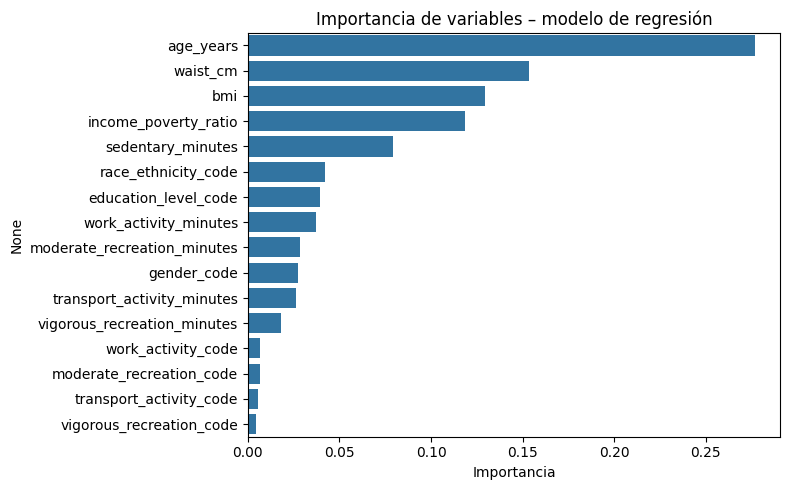

Este modelo no expone atributo feature_importances_.


In [23]:
# 6. Importancia de variables
def plot_feature_importances(model, feature_names, title):
    if not hasattr(model, "feature_importances_"):
        print("Este modelo no expone atributo feature_importances_.")
        return

    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(title)
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()

plot_feature_importances(reg_model, features.columns,
                         "Importancia de variables – modelo de regresión")

plot_feature_importances(clf_model, features.columns,
                         "Importancia de variables – clasificador")


### Importancia de variables – modelo de regresión (random forest)

El gráfico de importancia de variables del random forest de regresión indica qué características contribuyen más a la predicción de SBP_mean.

Las variables más relevantes son:

1. **age_years**  
2. **waist_cm**  
3. **bmi**  
4. **income_poverty_ratio**  
5. **sedentary_minutes**  

Seguidas por variables de actividad física, nivel educacional, raza/etnia y códigos de actividad. El patrón es coherente con el conocimiento clínico: mayor edad, obesidad central y contexto socioeconómico se asocian con mayor presión arterial, mientras que la actividad física y otros factores aportan información adicional pero menor.
